# TDCRPy — the Čerenkov model, worked through with Y-90

## What this notebook is for

`TDCR_model_lib.modelCerenkov` computes TDCR detection efficiencies for a
radionuclide counted by its **Čerenkov light** rather than by scintillation.
There is no scintillator and no cocktail: the sample is simply an aqueous
solution in a vial, and the light comes from the medium itself. This notebook
is a practical guide to that model, using **Y-90** as the worked example.

Y-90 is the reference case for Čerenkov counting. It is a pure β⁻ emitter with
$E_{max} = 2280$ keV, so a large part of its spectrum sits above the Čerenkov
threshold, and it is measured this way routinely — for radiopharmaceuticals
(⁹⁰Y-labelled microspheres and antibodies) and in ⁹⁰Sr/⁹⁰Y equilibrium sources,
where Čerenkov counting discriminates the daughter from the parent almost for
free (section 7).

## The physics the model implements

A charged particle travelling through a medium of refractive index $n$ faster
than light does in that medium radiates. The condition is

$$\beta > \frac{1}{n} \qquad\Longleftrightarrow\qquad
  E > E_{thr} = m_ec^2\left(\frac{1}{\sqrt{1-1/n^{2}}} - 1\right)$$

Above it, the **Frank–Tamm** relation gives the number of photons emitted per
unit path length in the wavelength window $[\lambda_{min}, \lambda_{max}]$ the
PMTs are sensitive to:

$$\frac{\mathrm{d}^2N}{\mathrm{d}x} =
  2\pi\alpha z^{2}\left(\frac{1}{\lambda_{min}}-\frac{1}{\lambda_{max}}\right)
  \left(1-\frac{1}{\beta^{2}n^{2}}\right)$$

`modelCerenkov` integrates this along the slowing-down track, converting path
length to energy with the stopping power $S(E)$, to get the total number of
Čerenkov photons produced by an electron of initial energy $E$:

$$m_{ck}(E) = \int_0^{E}
  \frac{1}{S(E')}\,\frac{\mathrm{d}^2N}{\mathrm{d}x}\,\mathrm{d}E'$$

Each PMT then sees a Poisson-distributed share of that light,
$\mu_i = L\,m_{ck}\,\alpha_i/3$, fires with probability $q_i = 1-e^{-\mu_i}$,
and the single / double / triple efficiencies follow by averaging over the
β spectrum.

> **`L` does not mean here what it means in the scintillation model.** In
> `modelAnalytical` / `TDCRPy`, `L` is a *light yield* in photons keV⁻¹ because
> the model still has to convert energy into photons. In `modelCerenkov` the
> photon count $m_{ck}$ is already absolute, so `L` is a **dimensionless
> detection factor** — quantum efficiency × light-collection efficiency.
> Expect values of order 0.1–1, not 1–10. (The `effA` docstring labels it
> keV⁻¹; that label is inherited from the scintillation path and does not
> apply here.)

## A note on the Y-90 data

Until now the Čerenkov model could not be run for Y-90: `readBetaSpectra` only
knew 13 nuclides and Y-90 was not one of them. The deposited-energy spectrum
`dep_spectrum_Y-90.txt` was generated for this notebook with
`TDCR_model_lib.buildBetaSpectra('Y-90', V=10, N=4e6)` — the same routine and
the same parameters that produced the 13 committed spectra (checked by
regenerating `dep_spectrum_Sr-90.txt`: identical energy grid, agreement to
< 2 × 10⁻⁴ in probability, i.e. Monte-Carlo noise) — and Y-90 was registered in
`_spectra_map`.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.integrate import cumulative_trapezoid
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

RAD  = 'Y-90'
MEC2 = 511.0          # electron rest mass, keV

# modelCerenkov's defaults, made explicit so they can be varied below
N_REF   = 1.341       # refractive index averaged over the PMT window
LAM_REF = (300, 650)  # nm, bialkali photocathode
ALPHA   = (1, 1, 1)   # anisotropy coefficients (a_A, a_B, a_C)
RHO, Z, A = 1.017, 7.55, 15.05   # medium, for the stopping power

TDCRPy 2.20.18


## 1. The Čerenkov threshold

Everything about Čerenkov counting follows from the threshold. Unlike
scintillation, where every keV deposited makes some light, here an electron
below $E_{thr}$ makes **exactly zero** photons and is completely invisible.

       n   beta_thr   E_thr (keV)
   1.333     0.7502         261.8
   1.341     0.7457         256.0
   1.360     0.7353         243.0
   1.400     0.7143         219.2
   1.500     0.6667         174.6

Y-90 deposited-energy spectrum: 425 points, 0 - 2278.7 keV
  mean deposited energy      = 539.5 keV
  threshold at n = 1.341      = 256.0 keV
  fraction of decays above it = 0.5613


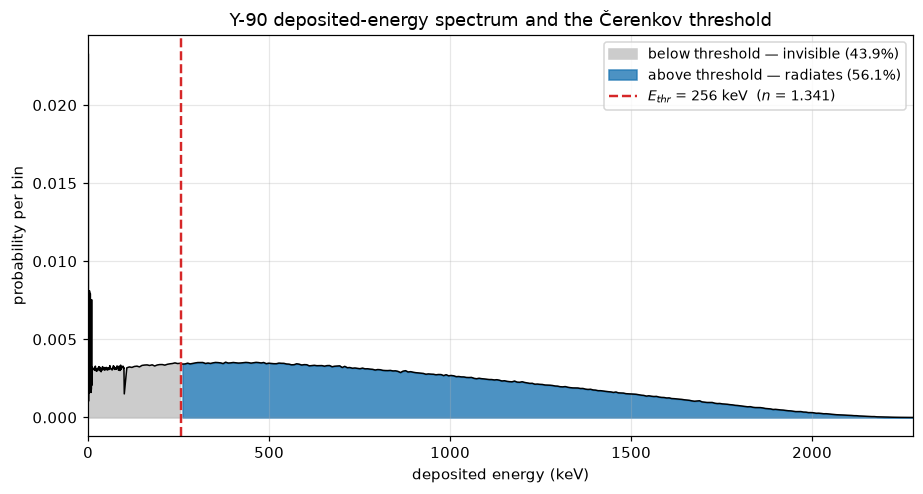

In [2]:
def threshold_keV(n):
    '''Čerenkov threshold kinetic energy for an electron in a medium of index n.'''
    beta_thr = 1.0 / n
    return (1.0 / np.sqrt(1.0 - beta_thr**2) - 1.0) * MEC2


print(f'{"n":>8s} {"beta_thr":>10s} {"E_thr (keV)":>13s}')
for n in (1.333, 1.341, 1.360, 1.400, 1.500):
    print(f'{n:8.3f} {1/n:10.4f} {threshold_keV(n):13.1f}')

e_dep, p_dep = tl.readBetaSpectra(RAD)
e_dep, p_dep = np.asarray(e_dep), np.asarray(p_dep)
E_thr = threshold_keV(N_REF)
frac_above = p_dep[e_dep > E_thr].sum()

print(f'\n{RAD} deposited-energy spectrum: {len(e_dep)} points, '
      f'0 - {e_dep[-1]:.1f} keV')
print(f'  mean deposited energy      = {(e_dep*p_dep).sum():.1f} keV')
print(f'  threshold at n = {N_REF}      = {E_thr:.1f} keV')
print(f'  fraction of decays above it = {frac_above:.4f}')

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.fill_between(e_dep, 0, p_dep, where=e_dep <= E_thr, color='#cccccc',
                label=f'below threshold — invisible ({1-frac_above:.1%})')
ax.fill_between(e_dep, 0, p_dep, where=e_dep > E_thr, color='#1f77b4', alpha=0.8,
                label=f'above threshold — radiates ({frac_above:.1%})')
ax.plot(e_dep, p_dep, '-k', lw=1)
ax.axvline(E_thr, color='#d62728', lw=1.6, ls='--',
           label=f'$E_{{thr}}$ = {E_thr:.0f} keV  ($n$ = {N_REF})')
ax.set_xlabel('deposited energy (keV)'); ax.set_ylabel('probability per bin')
ax.set_title(f'{RAD} deposited-energy spectrum and the Čerenkov threshold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0, e_dep[-1])
plt.tight_layout(); plt.savefig('cerenkov_Y90_threshold.png', dpi=150,
                                bbox_inches='tight')
plt.show()

## 2. The photon yield $m_{ck}(E)$

The function below reproduces exactly what `modelCerenkov` does internally. It
is written out here so the pieces are visible and so the optics can be varied —
and it is checked against `modelCerenkov` at the end of the section.

Frank-Tamm prefactor over (300, 650) nm : 823.0 photons/cm (at beta = 1)
maximum kinematic factor 1 - 1/n^2     : 0.4439

Y-90: photons produced by an electron of energy E
  E =    100 keV -> m_ck =     0.0 photons
  E =    256 keV -> m_ck =     0.0 photons
  E =    300 keV -> m_ck =     0.7 photons
  E =    500 keV -> m_ck =    15.5 photons
  E =   1000 keV -> m_ck =    90.3 photons
  E =   1500 keV -> m_ck =   181.7 photons
  E =   2279 keV -> m_ck =   330.8 photons

mean number of Čerenkov photons per Y-90 decay = 46.20


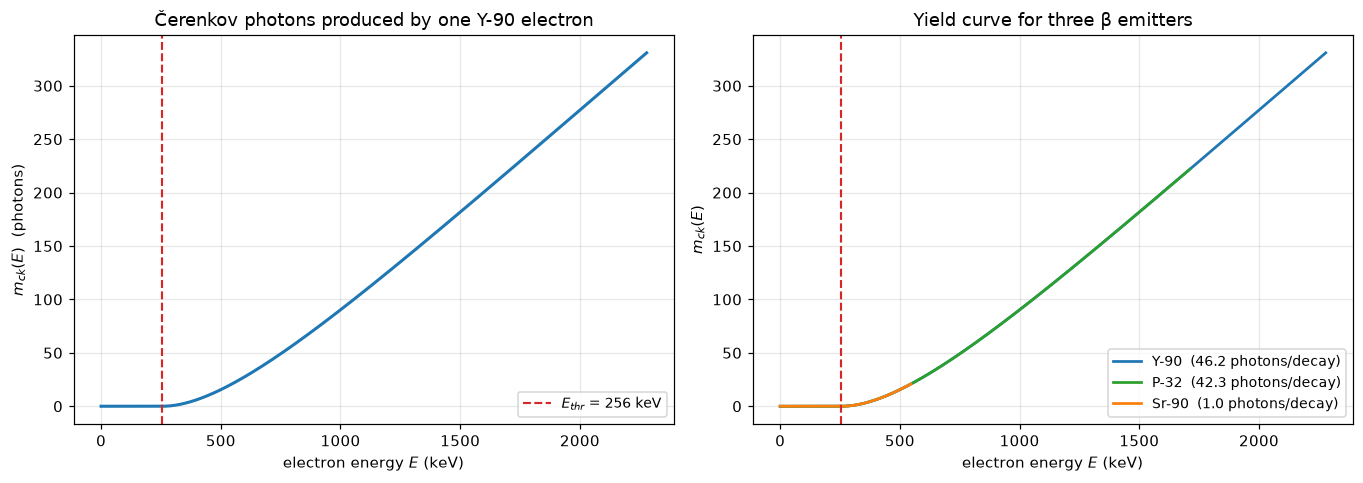

In [3]:
ALPHA_FS = 1.0 / 137.036


def cerenkov_yield(rad, n=N_REF, lambda_range=LAM_REF, rho=RHO, Z=Z, A=A):
    '''Return (E, p, m_ck): energy grid, spectrum, Čerenkov photons per electron.

    Mirrors the internals of TDCR_model_lib.modelCerenkov.'''
    e_keV, p = tl.readBetaSpectra(rad)
    e_keV, p = np.asarray(e_keV), np.asarray(p)

    l_min_cm, l_max_cm = lambda_range[0] * 1e-7, lambda_range[1] * 1e-7
    ft_constant = 2 * np.pi * ALPHA_FS * (1.0 / l_min_cm - 1.0 / l_max_cm)

    dEdx = np.array([tl.stoppingpower(E * 1e3, rho=rho, Z=Z, A=A,
                                      spmodel='tan_xia') for E in e_keV])

    gamma = (e_keV + MEC2) / MEC2
    beta = np.sqrt(1.0 - 1.0 / gamma**2)
    kinematic = np.where(beta > 1.0 / n, 1.0 - 1.0 / ((beta * n)**2), 0.0)

    with np.errstate(divide='ignore', invalid='ignore'):
        integrand = ft_constant * kinematic / dEdx
    integrand[~np.isfinite(integrand)] = 0.0

    m_ck = cumulative_trapezoid(integrand, x=e_keV * 1e-3, initial=0)
    return e_keV, p, m_ck


e, p, m_ck = cerenkov_yield(RAD)
print(f'Frank-Tamm prefactor over {LAM_REF} nm : '
      f'{2*np.pi*ALPHA_FS*(1/(LAM_REF[0]*1e-7) - 1/(LAM_REF[1]*1e-7)):.1f} photons/cm '
      f'(at beta = 1)')
print(f'maximum kinematic factor 1 - 1/n^2     : {1 - 1/N_REF**2:.4f}')
print(f'\n{RAD}: photons produced by an electron of energy E')
for E in (100, 256, 300, 500, 1000, 1500, 2279):
    print(f'  E = {E:6.0f} keV -> m_ck = {np.interp(E, e, m_ck):7.1f} photons')
print(f'\nmean number of Čerenkov photons per {RAD} decay = {(p*m_ck).sum():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
axes[0].plot(e, m_ck, '-', color='#1f77b4', lw=2)
axes[0].axvline(E_thr, color='#d62728', ls='--', lw=1.4,
                label=f'$E_{{thr}}$ = {E_thr:.0f} keV')
axes[0].set_xlabel('electron energy $E$ (keV)')
axes[0].set_ylabel('$m_{ck}(E)$  (photons)')
axes[0].set_title(f'Čerenkov photons produced by one {RAD} electron')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for rad, col in zip(('Y-90', 'P-32', 'Sr-90'), ('#1f77b4', '#2ca02c', '#ff7f0e')):
    ei, pi, mi = cerenkov_yield(rad)
    axes[1].plot(ei, mi, '-', color=col, lw=1.8,
                 label=f'{rad}  ({(pi*mi).sum():.1f} photons/decay)')
axes[1].axvline(E_thr, color='#d62728', ls='--', lw=1.4)
axes[1].set_xlabel('electron energy $E$ (keV)'); axes[1].set_ylabel('$m_{ck}(E)$')
axes[1].set_title('Yield curve for three β emitters')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('cerenkov_Y90_yield.png', dpi=150,
                                bbox_inches='tight')
plt.show()

In [4]:
# Cross-check: rebuild the efficiencies from cerenkov_yield() and compare with
# modelCerenkov. They must agree to machine precision.
def efficiencies_from_yield(L, m_ck, p, alpha=ALPHA):
    LA, LB, LC = (L, L, L) if np.isscalar(L) else L
    qA = 1 - np.exp(-LA * m_ck * alpha[0] / 3.0)
    qB = 1 - np.exp(-LB * m_ck * alpha[1] / 3.0)
    qC = 1 - np.exp(-LC * m_ck * alpha[2] / 3.0)
    eAB, eBC, eAC = np.sum(p*qA*qB), np.sum(p*qB*qC), np.sum(p*qA*qC)
    eT = np.sum(p * qA * qB * qC)
    eD = eAB + eBC + eAC - 2*eT
    eS = np.sum(p * (qA + qB + qC - (qA*qB + qB*qC + qA*qC) + qA*qB*qC))
    return eS, eD, eT


for L in (0.1, 0.35, 1.0):
    mine = efficiencies_from_yield(L, m_ck, p)
    lib = tl.modelCerenkov(L, 0, 0, 0, 0, RAD, 'eff')
    print(f'L={L:5.2f}  max|difference| = {max(abs(a-b) for a, b in zip(mine, lib)):.2e}')

L= 0.10  max|difference| = 0.00e+00
L= 0.35  max|difference| = 0.00e+00
L= 1.00  max|difference| = 0.00e+00


## 3. Efficiency as a function of the free parameter

This is the basic use of the model: `mode='eff'` returns
`(eff_S, eff_D, eff_T)` for a given `L`. The four ratio arguments
(`TD, TAB, TBC, TAC`) are ignored in this mode, so pass zeros.

```python
eff_S, eff_D, eff_T = tl.modelCerenkov(L, 0, 0, 0, 0, 'Y-90', 'eff')
```

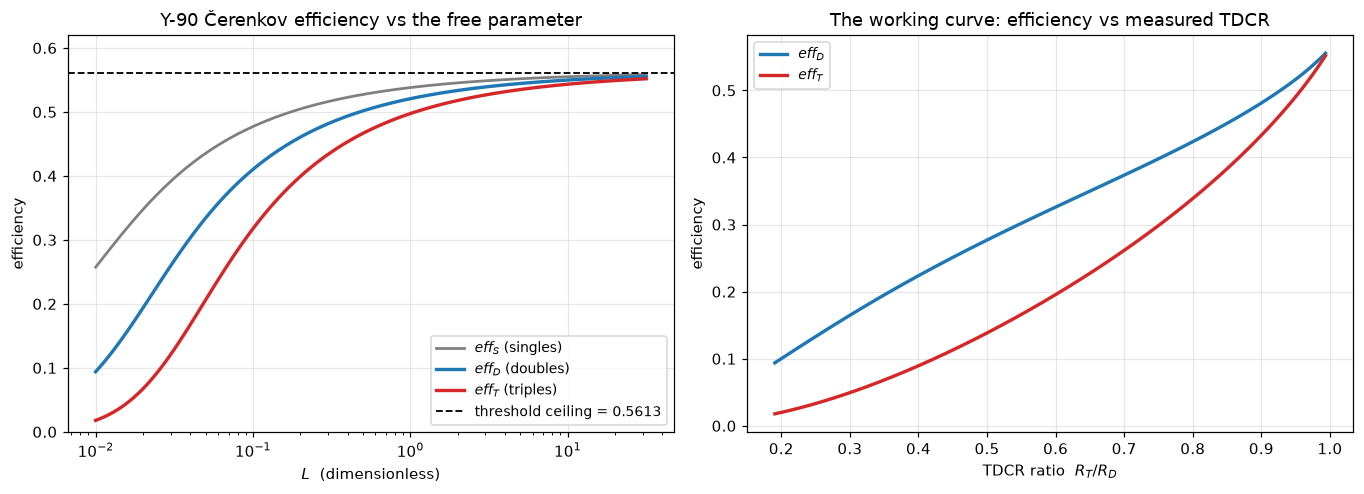

       L    eff_S    eff_D    eff_T     TDCR
    0.05   0.4353   0.3341   0.2061   0.6169
    0.10   0.4771   0.4101   0.3174   0.7740
    0.20   0.5046   0.4606   0.3991   0.8666
    0.35   0.5199   0.4883   0.4447   0.9107
    0.50   0.5273   0.5016   0.4665   0.9300
    1.00   0.5381   0.5207   0.4974   0.9554
    2.00   0.5455   0.5335   0.5179   0.9707
    5.00   0.5518   0.5445   0.5350   0.9826
 1000.00   0.5613   0.5613   0.5612   0.9997


In [5]:
L_vec = np.logspace(-2, 1.5, 120)
effS, effD, effT = [], [], []
for L in L_vec:
    S, D, T = tl.modelCerenkov(L, 0, 0, 0, 0, RAD, 'eff')
    effS.append(S); effD.append(D); effT.append(T)
effS, effD, effT = map(np.asarray, (effS, effD, effT))
tdcr = effT / effD

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].plot(L_vec, effS, '-', color='#7f7f7f', lw=1.8, label='$eff_S$ (singles)')
axes[0].plot(L_vec, effD, '-', color='#1f77b4', lw=2.2, label='$eff_D$ (doubles)')
axes[0].plot(L_vec, effT, '-', color='#d62728', lw=2.2, label='$eff_T$ (triples)')
axes[0].axhline(frac_above, color='k', ls='--', lw=1.2,
                label=f'threshold ceiling = {frac_above:.4f}')
axes[0].set_xscale('log'); axes[0].set_xlabel('$L$  (dimensionless)')
axes[0].set_ylabel('efficiency'); axes[0].set_ylim(0, 0.62)
axes[0].set_title(f'{RAD} Čerenkov efficiency vs the free parameter')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(tdcr, effD, '-', color='#1f77b4', lw=2.2, label='$eff_D$')
axes[1].plot(tdcr, effT, '-', color='#d62728', lw=2.2, label='$eff_T$')
axes[1].set_xlabel('TDCR ratio  $R_T/R_D$'); axes[1].set_ylabel('efficiency')
axes[1].set_title('The working curve: efficiency vs measured TDCR')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('cerenkov_Y90_efficiency.png', dpi=150,
                                bbox_inches='tight')
plt.show()

print(f'{"L":>8s} {"eff_S":>8s} {"eff_D":>8s} {"eff_T":>8s} {"TDCR":>8s}')
for L in (0.05, 0.1, 0.2, 0.35, 0.5, 1.0, 2.0, 5.0, 1000.0):
    S, D, T = tl.modelCerenkov(L, 0, 0, 0, 0, RAD, 'eff')
    print(f'{L:8.2f} {S:8.4f} {D:8.4f} {T:8.4f} {T/D:8.4f}')

**The threshold sets a hard ceiling on the efficiency.** As $L \to \infty$ all
three efficiencies converge to 0.5613 — exactly the fraction of the deposited
spectrum above $E_{thr}$ computed in section 1. No amount of light collection
recovers the 44 % of Y-90 decays that never cross the threshold. This is the
defining difference from scintillation counting, where the efficiency tends to
1, and it is why a Čerenkov TDCR curve is much flatter: `eff_D` only moves from
0.33 to 0.56 across the whole useful range of `L`.

## 4. Getting the efficiency from a measured TDCR ratio

The normal workflow. `TDCRPy.effA(..., cerenkov=True)` fits `L` so the model
reproduces the measured ratio, then returns the efficiencies at that `L`:

```python
L0, L_triplet, eff_S, eff_D, eff_T = tm.effA(
    TD, 'Y-90', 0, 0, 0, Lbounds=[0.01, 20], cerenkov=True)
```

`pmf_1`, `kB` and `V` (the three zeros) are part of the shared `effA` signature
and are **ignored** on the Čerenkov path — the model has no cocktail and no
Birks quenching.

To make the demonstration verifiable, the "measurement" below is synthesised
from the model itself at a known `L`, so the fit can be checked against the
truth. Substituting your own count rates is shown right after.

In [6]:
L_TRUE = 0.35
S_t, D_t, T_t = tl.modelCerenkov(L_TRUE, 0, 0, 0, 0, RAD, 'eff')
TD_meas = T_t / D_t
print(f'synthetic sample at L_true = {L_TRUE}:  TD = {TD_meas:.6f}')

L0, L_trip, eff_S, eff_D, eff_T = tm.effA(TD_meas, RAD, 0, 0, 0,
                                          Lbounds=[0.01, 20], cerenkov=True)
print(f'\nfitted L      = {L0:.6f}   (true {L_TRUE},'
      f' error {100*(L0-L_TRUE)/L_TRUE:+.4f} %)')
print(f'eff_S         = {eff_S:.5f}')
print(f'eff_D         = {eff_D:.5f}   <- use this to get the activity')
print(f'eff_T         = {eff_T:.5f}')
print(f'check TDCR    = {eff_T/eff_D:.6f}  vs measured {TD_meas:.6f}')

synthetic sample at L_true = 0.35:  TD = 0.910706

fitted L      = 0.350001   (true 0.35, error +0.0003 %)
eff_S         = 0.51987
eff_D         = 0.48828   <- use this to get the activity
eff_T         = 0.44468
check TDCR    = 0.910706  vs measured 0.910706


In [7]:
# --- with real data you would start from count rates ----------------------
# Replace these with your own background-corrected rates in s^-1.
R_T = 3150.0      # triple-coincidence rate
R_D = 4270.0      # logical-sum-of-doubles rate

TD_real = R_T / R_D
L0r, _, S_r, D_r, T_r = tm.effA(TD_real, RAD, 0, 0, 0,
                                Lbounds=[0.01, 20], cerenkov=True)
activity = R_D / D_r          # Bq, if the rates are in s^-1
print(f'measured TDCR   = {TD_real:.5f}')
print(f'fitted L        = {L0r:.5f}')
print(f'eff_D           = {D_r:.5f}')
print(f'activity        = R_D / eff_D = {activity:.1f} Bq')

# Always confirm the fit actually reproduced the ratio you asked for.
# 1e-4 is a realistic bar: effA's bounded search inherits fminbound's default
# xatol = 1e-5 on L, which floors the achievable TDCR residual near 1e-6.
# Raising maxiter does not help -- xatol is what binds.
resid = abs(T_r/D_r - TD_real)
assert resid < 1e-4, f'the L fit did not converge (residual {resid:.2e})'
print(f'\nfit verified: model TDCR reproduces the measurement to {resid:.1e}')

measured TDCR   = 0.73770
fitted L        = 0.08256
eff_D           = 0.39200
activity        = R_D / eff_D = 10892.9 Bq

fit verified: model TDCR reproduces the measurement to 2.1e-06


**Always check the fit.** `effA` returns no convergence flag, so a bounded
search that fails — a bad bracket, or a TD outside the range the model can
reach — comes back silently as a plausible-looking number. The `assert` above
is the cheap insurance.

Pick the tolerance realistically. The bounded search inherits
`scipy.optimize.fminbound`'s default `xatol = 1e-5` **on `L`**, which puts a
floor of roughly 1e-6 on the achievable TDCR residual, so asking for 1e-6 or
tighter fails on a perfectly converged fit — and raising `maxiter` will not
help, because `xatol` and not the iteration count is what binds. Anything below
1e-4 is already far inside the measurement uncertainty.

For Y-90 the modelled TDCR is monotonic in `L` over the whole range tested
below, so a wide `Lbounds` is safe here — but that is a property of this
nuclide, not a general guarantee.

In [8]:
# Is TDCR(L) monotonic for Y-90? (it is not for every nuclide)
L_probe = np.logspace(-2, 2, 60)
td_probe = np.array([(lambda S, D, T: T / D)(
                         *tl.modelCerenkov(L, 0, 0, 0, 0, RAD, 'eff'))
                     for L in L_probe])
print(f'TDCR range over L in [0.01, 100]: {td_probe.min():.4f} .. {td_probe.max():.4f}')
print(f'monotonically increasing: {bool(np.all(np.diff(td_probe) > 0))}')
print(f'\nreachable TD interval -> any measured TDCR inside it can be fitted;')
print(f'a measured value outside it means the model or the optics are wrong.')

TDCR range over L in [0.01, 100]: 0.1906 .. 0.9963
monotonically increasing: True

reachable TD interval -> any measured TDCR inside it can be fitted;
a measured value outside it means the model or the optics are wrong.


## 5. Asymmetric PMTs — fitting three free parameters

If the three PMTs do not have the same detection efficiency, pass the four
measured ratios `[TD, T/AB, T/BC, T/AC]` instead of a scalar. `effA` then
refines a triplet $(L_A, L_B, L_C)$ with a Nelder–Mead simplex after the
scalar search.

In [9]:
L_TRIPLET = (0.45, 0.35, 0.28)     # a deliberately unbalanced counter

_, _, m_ck_ref = cerenkov_yield(RAD)


def all_ratios(L, m_ck, p, alpha=ALPHA):
    '''TD, T/AB, T/BC, T/AC for a given (possibly asymmetric) L.'''
    LA, LB, LC = (L, L, L) if np.isscalar(L) else L
    qA = 1 - np.exp(-LA * m_ck * alpha[0] / 3.0)
    qB = 1 - np.exp(-LB * m_ck * alpha[1] / 3.0)
    qC = 1 - np.exp(-LC * m_ck * alpha[2] / 3.0)
    eAB, eBC, eAC = np.sum(p*qA*qB), np.sum(p*qB*qC), np.sum(p*qA*qC)
    eT = np.sum(p * qA * qB * qC)
    eD = eAB + eBC + eAC - 2*eT
    return eT/eD, eT/eAB, eT/eBC, eT/eAC


TD_a, TAB, TBC, TAC = all_ratios(L_TRIPLET, m_ck_ref, p)
print(f'synthetic asymmetric sample, L = {L_TRIPLET}')
print(f'  TD = {TD_a:.5f}   T/AB = {TAB:.5f}   T/BC = {TBC:.5f}   T/AC = {TAC:.5f}')

res = tm.effA([TD_a, TAB, TBC, TAC], RAD, 0, 0, 0, Lbounds=[0.01, 20],
              cerenkov=True, maxiter=200, xatol=1e-9)
print(f'\nglobal (symmetric) L0 = {res[0]:.5f}')
print(f'fitted triplet        = ({res[1][0]:.5f}, {res[1][1]:.5f}, {res[1][2]:.5f})')
print(f'true triplet          = {L_TRIPLET}')
print(f'\neff_S = {res[2]:.5f}   eff_D = {res[3]:.5f}   eff_T = {res[4]:.5f}')

synthetic asymmetric sample, L = (0.45, 0.35, 0.28)
  TD = 0.90691   T/AB = 0.95170   T/BC = 0.98111   T/AC = 0.96840



global (symmetric) L0 = 0.32978
fitted triplet        = (0.45000, 0.35000, 0.28000)
true triplet          = (0.45, 0.35, 0.28)

eff_S = 0.52051   eff_D = 0.48878   eff_T = 0.44328


## 6. The optical parameters, and a limitation of `effA`

`modelCerenkov` exposes the medium and the optics as keyword arguments:

| argument | default | meaning |
|---|---|---|
| `n` | 1.341 | refractive index, averaged over the PMT window |
| `lambda_range` | (300, 650) | PMT sensitivity window in nm (bialkali) |
| `alpha` | (1, 1, 1) | anisotropy coefficients; 0.79 for glass/polyethylene vials, after Grau Malonda & Grau Carles (1998) |
| `rho`, `Z`, `A` | 1.017, 7.55, 15.05 | medium properties, used by the stopping power |

Water is $n = 1.333$ at 589 nm, but $n$ rises towards the UV, so 1.341 is a
sensible average over 300–650 nm. The window matters a lot: the Frank–Tamm
prefactor goes as $1/\lambda_{min} - 1/\lambda_{max}$, so extending into the UV
buys photons quickly.

In [10]:
print('effect of the refractive index (L = 0.35)')
for n in (1.333, N_REF, 1.360, 1.400):
    S, D, T = tl.modelCerenkov(0.35, 0, 0, 0, 0, RAD, 'eff', n=n)
    print(f'  n = {n:.3f}  E_thr = {threshold_keV(n):6.1f} keV   '
          f'eff_D = {D:.4f}  TDCR = {T/D:.4f}')

print('\neffect of the PMT wavelength window (L = 0.35)')
for lam in ((350, 600), LAM_REF, (280, 650), (160, 630)):
    S, D, T = tl.modelCerenkov(0.35, 0, 0, 0, 0, RAD, 'eff', lambda_range=lam)
    print(f'  {str(lam):12s}  eff_D = {D:.4f}  TDCR = {T/D:.4f}')

print('\neffect of the anisotropy coefficients (L = 0.35)')
for a in (ALPHA, (0.79, 0.79, 0.79), (1.0, 0.9, 0.8)):
    S, D, T = tl.modelCerenkov(0.35, 0, 0, 0, 0, RAD, 'eff', alpha=a)
    print(f'  {str(a):18s}  eff_D = {D:.4f}  TDCR = {T/D:.4f}')

effect of the refractive index (L = 0.35)
  n = 1.333  E_thr =  261.8 keV   eff_D = 0.4844  TDCR = 0.9089
  n = 1.341  E_thr =  256.0 keV   eff_D = 0.4883  TDCR = 0.9107
  n = 1.360  E_thr =  243.0 keV   eff_D = 0.4969  TDCR = 0.9147
  n = 1.400  E_thr =  219.2 keV   eff_D = 0.5127  TDCR = 0.9218

effect of the PMT wavelength window (L = 0.35)
  (350, 600)    eff_D = 0.4689  TDCR = 0.8804
  (300, 650)    eff_D = 0.4883  TDCR = 0.9107
  (280, 650)    eff_D = 0.4933  TDCR = 0.9181
  (160, 630)    eff_D = 0.5185  TDCR = 0.9526

effect of the anisotropy coefficients (L = 0.35)
  (1, 1, 1)           eff_D = 0.4883  TDCR = 0.9107
  (0.79, 0.79, 0.79)  eff_D = 0.4778  TDCR = 0.8946
  (1.0, 0.9, 0.8)     eff_D = 0.4836  TDCR = 0.9025


### `effA(cerenkov=True)` does not forward these arguments

Look at how `effA` builds its argument tuple on the Čerenkov path:

```python
return (td_scalar, td_scalar, td_scalar, td_scalar, Rad, "res")
```

`n`, `lambda_range`, `alpha`, `rho`, `Z` and `A` are never passed, so **every
fit through `effA` silently uses the defaults**. If your counter is not
`n = 1.341` with a 300–650 nm bialkali window, drive the optimiser yourself —
it is three lines.

In [11]:
N_CUSTOM, LAM_CUSTOM = 1.36, (280, 650)
L_TRUE_C = 0.30

# a sample measured on a counter with those optics
_, D_c, T_c = tl.modelCerenkov(L_TRUE_C, 0, 0, 0, 0, RAD, 'eff',
                               n=N_CUSTOM, lambda_range=LAM_CUSTOM)
TD_c = T_c / D_c
print(f'counter with n = {N_CUSTOM}, window {LAM_CUSTOM} nm')
print(f'  true L = {L_TRUE_C},  measured TD = {TD_c:.5f},  true eff_D = {D_c:.5f}\n')

# (a) the convenient but wrong way: effA, which assumes the default optics
L_bad, _, _, D_bad, T_bad = tm.effA(TD_c, RAD, 0, 0, 0, Lbounds=[0.01, 20],
                                    cerenkov=True)
print(f'(a) effA, default optics : L = {L_bad:.5f}  eff_D = {D_bad:.5f}')

# (b) the correct way: minimise modelCerenkov yourself with matching optics
fit = opt.minimize_scalar(
    lambda LL: tl.modelCerenkov(LL, TD_c, 0, 0, 0, RAD, 'res',
                                n=N_CUSTOM, lambda_range=LAM_CUSTOM),
    bounds=(0.01, 20), method='bounded', options={'maxiter': 200})
S_ok, D_ok, T_ok = tl.modelCerenkov(fit.x, 0, 0, 0, 0, RAD, 'eff',
                                    n=N_CUSTOM, lambda_range=LAM_CUSTOM)
print(f'(b) direct, matched optics: L = {fit.x:.5f}  eff_D = {D_ok:.5f}')

print(f'\nbias from using the wrong optics:')
print(f'  on L     : {100*(L_bad-L_TRUE_C)/L_TRUE_C:+7.2f} %')
print(f'  on eff_D : {100*(D_bad-D_c)/D_c:+7.2f} %   <- what actually matters')
assert abs(T_ok/D_ok - TD_c) < 1e-4

counter with n = 1.36, window (280, 650) nm
  true L = 0.3,  measured TD = 0.91292,  true eff_D = 0.49572

(a) effA, default optics : L = 0.36284  eff_D = 0.48976
(b) direct, matched optics: L = 0.30000  eff_D = 0.49572

bias from using the wrong optics:
  on L     :  +20.95 %
  on eff_D :   -1.20 %   <- what actually matters


The `L` is off by more than 20 %, but `eff_D` only by about 1 %. That is the
usual TDCR self-correction: the ratio constrains the efficiency far better than
it constrains the free parameter, so an optics error is partly reabsorbed into
`L`. Useful to know, but not a licence to ignore the optics — the residual
percent is systematic, not random, and it does not shrink with counting time.

## 7. Why Y-90, and why this works for ⁹⁰Sr/⁹⁰Y sources

The threshold makes Čerenkov counting extremely selective in energy. Comparing
the three β emitters TDCRPy has spectra for:

nuclide      E_max   <E_dep>   > E_thr   photons/decay   eff_D at L=0.35
------------------------------------------------------------------------
Y-90          2279       540    0.5613           46.20            0.4883
P-32          1711       621    0.8167           42.34            0.6815
Sr-90          546       190    0.3093            1.03            0.0742

Y-90 makes 45x more Čerenkov light per decay than Sr-90,
and is detected 6.6x more efficiently at the same L.


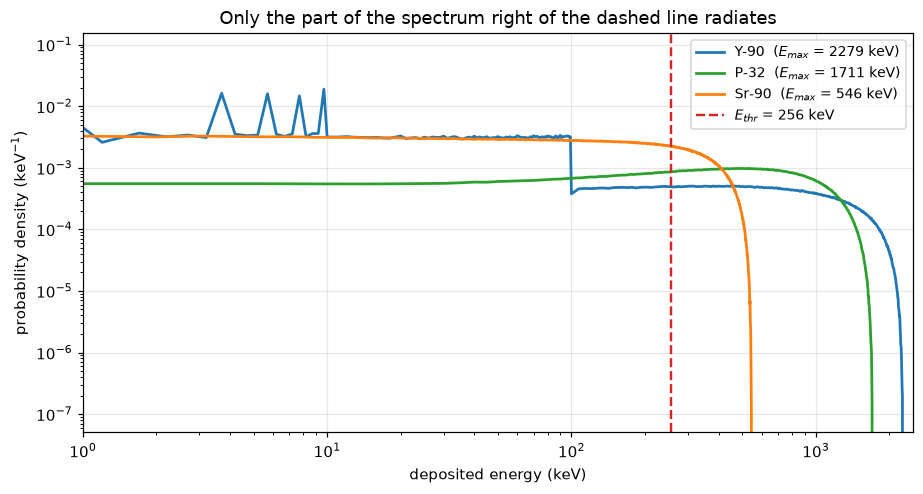

In [12]:
print(f'{"nuclide":9s} {"E_max":>8s} {"<E_dep>":>9s} {"> E_thr":>9s} '
      f'{"photons/decay":>15s} {"eff_D at L=0.35":>17s}')
print('-' * 72)
rows = {}
for rad in ('Y-90', 'P-32', 'Sr-90'):
    ei, pi, mi = cerenkov_yield(rad)
    above = pi[ei > E_thr].sum()
    _, Di, Ti = tl.modelCerenkov(0.35, 0, 0, 0, 0, rad, 'eff')
    rows[rad] = (ei[-1], (ei*pi).sum(), above, (pi*mi).sum(), Di)
    print(f'{rad:9s} {ei[-1]:8.0f} {(ei*pi).sum():9.0f} {above:9.4f} '
          f'{(pi*mi).sum():15.2f} {Di:17.4f}')

r_y, r_s = rows['Y-90'], rows['Sr-90']
print(f'\nY-90 makes {r_y[3]/r_s[3]:.0f}x more Čerenkov light per decay than Sr-90,')
print(f'and is detected {r_y[4]/r_s[4]:.1f}x more efficiently at the same L.')

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for rad, col in zip(('Y-90', 'P-32', 'Sr-90'), ('#1f77b4', '#2ca02c', '#ff7f0e')):
    ei, pi, _ = cerenkov_yield(rad)
    width = np.gradient(ei)                      # bin width, no zero entries
    ax.plot(ei, pi / width, '-', color=col, lw=1.8,
            label=f'{rad}  ($E_{{max}}$ = {ei[-1]:.0f} keV)')
ax.axvline(E_thr, color='#d62728', ls='--', lw=1.6,
           label=f'$E_{{thr}}$ = {E_thr:.0f} keV')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(1, 2500)
ax.set_xlabel('deposited energy (keV)')
ax.set_ylabel(r'probability density (keV$^{-1}$)')
ax.set_title('Only the part of the spectrum right of the dashed line radiates')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('cerenkov_Y90_comparison.png', dpi=150,
                                bbox_inches='tight')
plt.show()

Note first what the table does **not** say: Y-90 is not the most efficiently
counted of the three. P-32 is, at 0.68 against 0.49, because less of its
spectrum escapes a 10 mL vial (621 keV deposited on average against 540 keV)
and what remains is better placed relative to the threshold. Y-90's case rests
on selectivity and on practicality, not on raw efficiency.

The selectivity is the point. In a ⁹⁰Sr/⁹⁰Y source at secular equilibrium the
two nuclides have equal activity, so a scintillation counter sees both and the
measurement has to disentangle them. A Čerenkov counter at `L = 0.35` sees
Y-90 at `eff_D` = 0.488 and Sr-90 at 0.074 — a factor **6.6** in efficiency,
on top of the factor 45 in light produced per decay. About 87 % of the
double-coincidence rate then comes from the daughter, so the Y-90 activity is
measured almost directly and the Sr-90 contribution enters as a small
correction rather than as a second unknown.

The same selectivity, plus the absence of any cocktail, quench correction or
sample chemistry — and the fact that the sample stays recoverable — is what
makes Čerenkov counting attractive for ⁹⁰Y radiopharmaceuticals.

## 8. Summary and caveats

**The recipe.**

```python
import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

# efficiency at a chosen free parameter
eff_S, eff_D, eff_T = tl.modelCerenkov(L, 0, 0, 0, 0, 'Y-90', 'eff')

# free parameter and efficiency from a measured TDCR ratio
L0, L_trip, eff_S, eff_D, eff_T = tm.effA(
    R_T/R_D, 'Y-90', 0, 0, 0, Lbounds=[0.01, 20], cerenkov=True)

activity = R_D / eff_D
```

**What to keep in mind.**

* `L` is a **dimensionless** detection factor here (QE × collection), typically
  0.1–1 — not the photons keV⁻¹ of the scintillation model, despite what the
  `effA` docstring says.
* The efficiency is **capped by the threshold**, at 0.5613 for Y-90 with
  $n = 1.341$. Efficiencies close to 1 are not attainable, and a fitted `eff_D`
  approaching 0.56 means the counter is already light-saturated.
* `effA(cerenkov=True)` **ignores** `n`, `lambda_range`, `alpha`, `rho`, `Z`
  and `A`. Fit `modelCerenkov` directly if your optics differ from the
  defaults (section 6).
* `effA` returns **no convergence flag**. Check `eff_T/eff_D` against the ratio
  you supplied.
* `kB` and `V` are inert on this path — there is no cocktail and no Birks
  quenching to apply.
* The model integrates the yield over the **deposited**-energy spectrum, which
  for Y-90 in a 10 mL vial averages 540 keV against 926 keV emitted: a 2.28 MeV
  electron often leaves the vial. Treating the escaping electron as one that
  slowed fully from its deposited energy is an approximation — it gets the
  in-volume path roughly right, but the exact Čerenkov yield of a track that
  exits while still above threshold is not modelled.
* Čerenkov emission is strongly **directional** (light is emitted on a cone at
  $\cos\theta = 1/\beta n$). The model handles this only through the scalar
  `alpha` coefficients and an equal three-way split of the photons; it is not a
  geometric optical transport.

**See also.** [`cerenkovModel.ipynb`](cerenkovModel.ipynb) — the compact
reference version of this workflow, with P-32.
[`analyticalModel.ipynb`](analyticalModel.ipynb) — the scintillation
counterpart, `effA` without `cerenkov=True`.
[`Sr-90_Y-90.ipynb`](../nuclides/Sr-90_Y-90.ipynb) — the same pair measured by
scintillation.